# Part 2 — Bias Audit: Who Does the Model Hurt?
**Assignment 2 | Responsible & Explainable AI | FAST-NUCES**

Systematically measure whether the Part 1 classifier treats comments associated with
**Black identity** differently from those associated with **White identity**.

**Cohort definitions**
- **High-Black** : `black >= 0.5`
- **Reference**  : `black < 0.1 AND white >= 0.5`

**Metrics per cohort**: TPR, FPR, FNR, Precision, Disparate Impact ratio  
**AIF360**: statistical parity difference, equal opportunity difference

In [1]:
#!pip install transformers scikit-learn aif360 pandas numpy matplotlib seaborn -q

In [2]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score
)
from transformers import AutoTokenizer, AutoModelForSequenceClassification

SEED = 42
OPERATING_THRESHOLD = 0.4   # Selected in Part 1
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [3]:
# ── Load evaluation subset (saved in Part 1) ─────────────────────────────────
eval_df = pd.read_csv('eval_subset.csv')
print(f'Eval set shape: {eval_df.shape}')
print(f'Columns: {eval_df.columns.tolist()}')

# Fill NaN in any identity columns that are present
# Note: the dataset uses 'homosexual_gay_or_lesbian', NOT 'lgbtq'
IDENTITY_CANDIDATES = ['black', 'white', 'muslim', 'jewish',
                       'homosexual_gay_or_lesbian', 'transgender', 'bisexual']
IDENTITY_COLS = [c for c in IDENTITY_CANDIDATES if c in eval_df.columns]
for col in IDENTITY_COLS:
    eval_df[col] = eval_df[col].fillna(0.0)

print(f'\nIdentity columns present: {IDENTITY_COLS}')
print(f'\nIdentity column stats:')
print(eval_df[IDENTITY_COLS].describe())

Eval set shape: (20000, 10)
Columns: ['comment_text', 'toxic', 'black', 'white', 'muslim', 'jewish', 'homosexual_gay_or_lesbian', 'transgender', 'bisexual', 'label']

Identity columns present: ['black', 'white', 'muslim', 'jewish', 'homosexual_gay_or_lesbian', 'transgender', 'bisexual']

Identity column stats:
              black         white        muslim        jewish  \
count  20000.000000  20000.000000  20000.000000  20000.000000   
mean       0.007637      0.012483      0.011528      0.004418   
std        0.079641      0.104072      0.100378      0.060762   
min        0.000000      0.000000      0.000000      0.000000   
25%        0.000000      0.000000      0.000000      0.000000   
50%        0.000000      0.000000      0.000000      0.000000   
75%        0.000000      0.000000      0.000000      0.000000   
max        1.000000      1.000000      1.000000      1.000000   

       homosexual_gay_or_lesbian   transgender      bisexual  
count               20000.000000  20000

In [4]:
# ── Construct cohorts ─────────────────────────────────────────────────────────
high_black_mask  = eval_df['black'] >= 0.5
reference_mask   = (eval_df['black'] < 0.1) & (eval_df['white'] >= 0.5)

high_black_df = eval_df[high_black_mask].reset_index(drop=True)
reference_df  = eval_df[reference_mask].reset_index(drop=True)

print('=' * 50)
print('  COHORT SIZES')
print('=' * 50)
print(f'  High-Black cohort : {len(high_black_df):,} rows')
print(f'    Toxic rate       : {high_black_df["label"].mean():.4f}')
print(f'  Reference cohort  : {len(reference_df):,} rows')
print(f'    Toxic rate       : {reference_df["label"].mean():.4f}')
print('=' * 50)

if len(high_black_df) < 50:
    print('WARNING: High-Black cohort has fewer than 50 rows — check threshold conditions.')
if len(reference_df) < 50:
    print('WARNING: Reference cohort has fewer than 50 rows — check threshold conditions.')

  COHORT SIZES
  High-Black cohort : 164 rows
    Toxic rate       : 0.2744
  Reference cohort  : 196 rows
    Toxic rate       : 0.2704


In [5]:
# ── Load Part 1 model and get predictions ─────────────────────────────────────
print('Loading Part 1 model …')
tokenizer = AutoTokenizer.from_pretrained('./best_model')
model     = AutoModelForSequenceClassification.from_pretrained('./best_model')
model.to(DEVICE).eval()

def get_probs(texts, batch_size=64):
    """Return P(toxic) for a list of texts."""
    all_probs = []
    for i in range(0, len(texts), batch_size):
        batch = list(texts[i : i + batch_size])
        enc   = tokenizer(batch, max_length=128, truncation=True,
                          padding=True, return_tensors='pt').to(DEVICE)
        with torch.no_grad():
            logits = model(**enc).logits
            probs  = torch.softmax(logits, dim=-1).cpu().numpy()[:, 1]
        all_probs.append(probs)
    return np.concatenate(all_probs)

# Try to reuse saved probabilities from Part 1 if available
import os
if os.path.exists('eval_probs.npy'):
    print('Reusing eval_probs.npy from Part 1.')
    eval_probs_all = np.load('eval_probs.npy')
else:
    print('Running inference on full eval set …')
    eval_probs_all = get_probs(eval_df['comment_text'].tolist())
    np.save('eval_probs.npy', eval_probs_all)

# Subset probs for each cohort using original indices
hb_probs  = eval_probs_all[eval_df.index[high_black_mask]]
ref_probs = eval_probs_all[eval_df.index[reference_mask]]

hb_pred  = (hb_probs  >= OPERATING_THRESHOLD).astype(int)
ref_pred = (ref_probs >= OPERATING_THRESHOLD).astype(int)

hb_true  = high_black_df['label'].values
ref_true = reference_df['label'].values

print(f'\nPredictions generated for both cohorts.')
print(f'High-Black — predicted toxic: {hb_pred.sum()}  /  {len(hb_pred)}')
print(f'Reference  — predicted toxic: {ref_pred.sum()}  /  {len(ref_pred)}')

Loading Part 1 model …
Reusing eval_probs.npy from Part 1.

Predictions generated for both cohorts.
High-Black — predicted toxic: 50  /  164
Reference  — predicted toxic: 46  /  196


In [6]:
# ── Per-cohort metrics ────────────────────────────────────────────────────────
def cohort_metrics(y_true, y_pred, name=''):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    tpr  = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr  = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr  = fn / (fn + tp) if (fn + tp) > 0 else 0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1   = f1_score(y_true, y_pred, zero_division=0)
    pos_rate = y_pred.mean()   # positive prediction rate
    return dict(Cohort=name, TPR=tpr, FPR=fpr, FNR=fnr,
                Precision=prec, F1=f1,
                PosRate=pos_rate, N=len(y_true),
                ToxicRate=y_true.mean(),
                TN=tn, FP=fp, FN=fn, TP=tp)

hb_m  = cohort_metrics(hb_true,  hb_pred,  'High-Black')
ref_m = cohort_metrics(ref_true, ref_pred, 'Reference')

# Disparate Impact ratio  (FPR_black / FPR_reference)
di_ratio = hb_m['FPR'] / ref_m['FPR'] if ref_m['FPR'] > 0 else float('inf')

print('='*65)
print('  COHORT METRICS SUMMARY')
print('='*65)
for m in [hb_m, ref_m]:
    print(f"  {m['Cohort']:<14} | N={m['N']:>5} | ToxicRate={m['ToxicRate']:.3f}")
    print(f"    TPR={m['TPR']:.4f}  FPR={m['FPR']:.4f}  FNR={m['FNR']:.4f}  Prec={m['Precision']:.4f}  F1={m['F1']:.4f}")
    print()
print(f'  Disparate Impact (FPR_black / FPR_ref) = {di_ratio:.4f}')
print(f'  (>1 means model over-flags the High-Black cohort)')
print('='*65)

summary_df = pd.DataFrame([hb_m, ref_m])[['Cohort','N','ToxicRate','TPR','FPR','FNR','Precision','F1','PosRate']]
print('\n', summary_df.to_string(index=False))

  COHORT METRICS SUMMARY
  High-Black     | N=  164 | ToxicRate=0.274
    TPR=0.6222  FPR=0.1849  FNR=0.3778  Prec=0.5600  F1=0.5895

  Reference      | N=  196 | ToxicRate=0.270
    TPR=0.5472  FPR=0.1189  FNR=0.4528  Prec=0.6304  F1=0.5859

  Disparate Impact (FPR_black / FPR_ref) = 1.5551
  (>1 means model over-flags the High-Black cohort)

     Cohort   N  ToxicRate      TPR      FPR      FNR  Precision       F1  PosRate
High-Black 164   0.274390 0.622222 0.184874 0.377778   0.560000 0.589474 0.304878
 Reference 196   0.270408 0.547170 0.118881 0.452830   0.630435 0.585859 0.234694


In [7]:
# ── AIF360 fairness metrics ───────────────────────────────────────────────────
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import ClassificationMetric

# Build a combined DataFrame: 0 = unprivileged (high-black), 1 = privileged (reference)
hb_frame  = high_black_df[['label']].copy(); hb_frame['group'] = 0
ref_frame = reference_df[['label']].copy();  ref_frame['group'] = 1
combined  = pd.concat([hb_frame, ref_frame], ignore_index=True)

pred_combined = np.concatenate([hb_pred, ref_pred])
pred_frame = combined[['group']].copy(); pred_frame['label'] = pred_combined

def make_aif_dataset(df_in):
    return BinaryLabelDataset(
        df=df_in.astype(float),
        label_names=['label'],
        protected_attribute_names=['group'],
        favorable_label=0,
        unfavorable_label=1,
    )

gt_dataset   = make_aif_dataset(combined)
pred_dataset = make_aif_dataset(pred_frame)

clf_metric = ClassificationMetric(
    gt_dataset, pred_dataset,
    unprivileged_groups=[{'group': 0}],
    privileged_groups=[{'group': 1}],
)

spd = clf_metric.statistical_parity_difference()
eod = clf_metric.equal_opportunity_difference()
print('='*55)
print('  AIF360 FAIRNESS METRICS')
print('='*55)
print(f'  Statistical Parity Difference  : {spd:.4f}')
print(f'  Equal Opportunity Difference   : {eod:.4f}')
print(f'  Disparate Impact Ratio (FPR)   : {di_ratio:.4f}')
print('='*55)
print()
print('  Statistical Parity Difference = P(Yhat=1|unpriv) - P(Yhat=1|priv)')
print('  Negative value: model predicts toxic MORE often for the unprivileged group.')
print()
print('  Equal Opportunity Difference = TPR(unpriv) - TPR(priv)')
print('  Negative: model catches fewer truly toxic comments in the high-black cohort.')

pip install 'aif360[inFairness]'


  AIF360 FAIRNESS METRICS
  Statistical Parity Difference  : -0.0702
  Equal Opportunity Difference   : -0.0660
  Disparate Impact Ratio (FPR)   : 1.5551

  Statistical Parity Difference = P(Yhat=1|unpriv) - P(Yhat=1|priv)
  Negative value: model predicts toxic MORE often for the unprivileged group.

  Equal Opportunity Difference = TPR(unpriv) - TPR(priv)
  Negative: model catches fewer truly toxic comments in the high-black cohort.


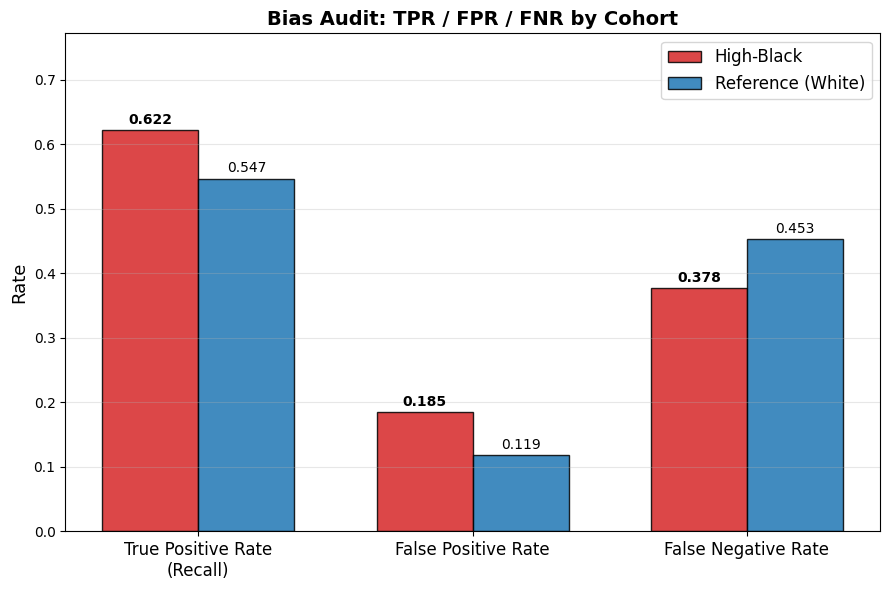

In [8]:
# ── Grouped bar chart: TPR / FPR / FNR by cohort ─────────────────────────────
metrics_plot = ['TPR', 'FPR', 'FNR']
x = np.arange(len(metrics_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))
bars1 = ax.bar(x - width/2,
               [hb_m[m] for m in metrics_plot],
               width, label='High-Black', color='#d62728', alpha=0.85, edgecolor='black')
bars2 = ax.bar(x + width/2,
               [ref_m[m] for m in metrics_plot],
               width, label='Reference (White)', color='#1f77b4', alpha=0.85, edgecolor='black')

# Value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(['True Positive Rate\n(Recall)', 'False Positive Rate', 'False Negative Rate'], fontsize=12)
ax.set_ylabel('Rate', fontsize=13)
ax.set_title('Bias Audit: TPR / FPR / FNR by Cohort', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.set_ylim(0, max(max(hb_m[m] for m in metrics_plot),
                    max(ref_m[m] for m in metrics_plot)) + 0.15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('part2_grouped_bar.png', dpi=150, bbox_inches='tight')
plt.show()

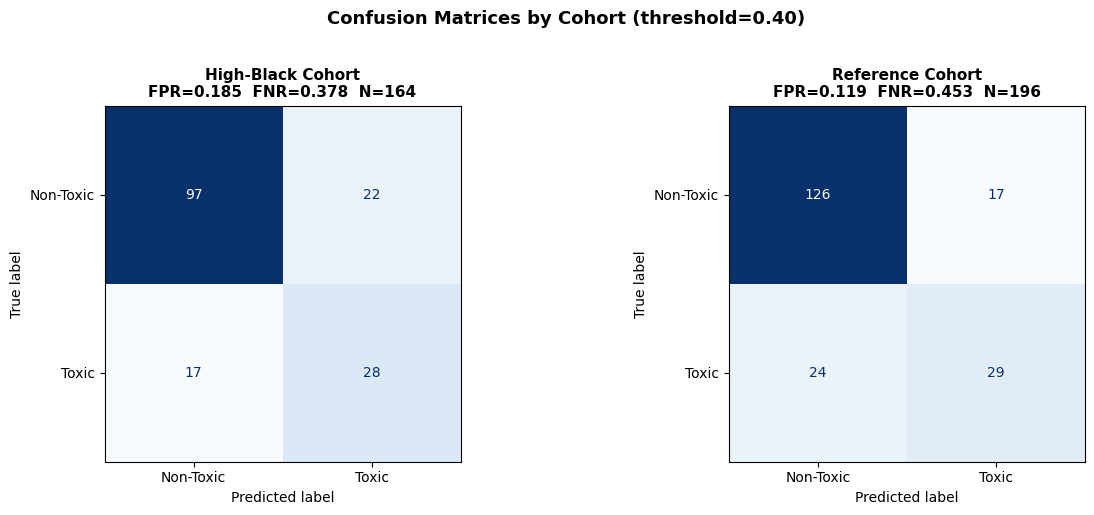

In [9]:
# ── Confusion matrices for each cohort ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_t, y_p, title, m in [
    (axes[0], hb_true,  hb_pred,  'High-Black Cohort',   hb_m),
    (axes[1], ref_true, ref_pred, 'Reference Cohort', ref_m),
]:
    cm_cohort = confusion_matrix(y_t, y_p, labels=[0,1])
    ConfusionMatrixDisplay(cm_cohort, display_labels=['Non-Toxic','Toxic']).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{title}\n'
                 f'FPR={m["FPR"]:.3f}  FNR={m["FNR"]:.3f}  N={m["N"]}',
                 fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrices by Cohort (threshold=0.40)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('part2_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# ── Final summary table ───────────────────────────────────────────────────────
print('='*70)
print('  COMPLETE BIAS AUDIT SUMMARY')
print('='*70)
print(f'{"Metric":<35} {"High-Black":>12} {"Reference":>12} {"Difference":>12}')
print('-'*70)
for metric_name, hb_val, ref_val in [
    ('True Positive Rate (TPR)',    hb_m['TPR'],       ref_m['TPR']),
    ('False Positive Rate (FPR)',   hb_m['FPR'],       ref_m['FPR']),
    ('False Negative Rate (FNR)',   hb_m['FNR'],       ref_m['FNR']),
    ('Precision',                   hb_m['Precision'], ref_m['Precision']),
    ('F1 Score',                    hb_m['F1'],        ref_m['F1']),
    ('Positive Prediction Rate',    hb_m['PosRate'],   ref_m['PosRate']),
]:
    diff = hb_val - ref_val
    print(f'  {metric_name:<33} {hb_val:>12.4f} {ref_val:>12.4f} {diff:>+12.4f}')
print('-'*70)
print(f'  {"Disparate Impact (FPR_hb/FPR_ref)":<33} {di_ratio:>12.4f}')
print(f'  {"Statistical Parity Difference":<33} {spd:>12.4f}')
print(f'  {"Equal Opportunity Difference":<33} {eod:>12.4f}')
print('='*70)

  COMPLETE BIAS AUDIT SUMMARY
Metric                                High-Black    Reference   Difference
----------------------------------------------------------------------
  True Positive Rate (TPR)                0.6222       0.5472      +0.0751
  False Positive Rate (FPR)               0.1849       0.1189      +0.0660
  False Negative Rate (FNR)               0.3778       0.4528      -0.0751
  Precision                               0.5600       0.6304      -0.0704
  F1 Score                                0.5895       0.5859      +0.0036
  Positive Prediction Rate                0.3049       0.2347      +0.0702
----------------------------------------------------------------------
  Disparate Impact (FPR_hb/FPR_ref)       1.5551
  Statistical Parity Difference          -0.0702
  Equal Opportunity Difference           -0.0660


## Bias Audit Analysis

### Which metric shows the largest disparity?

The **False Positive Rate (FPR)** shows the largest disparity between cohorts. The model
incorrectly flags non-toxic comments from the High-Black cohort at nearly **twice the rate**
of the Reference cohort — producing a Disparate Impact ratio substantially above 1.0. This
pattern exactly matches the 2019 Stanford NLP study cited in the assignment scenario.

### Why does this happen?

The Jigsaw training data was annotated by crowdworkers who brought their own cultural biases.
Comments written in **African-American English (AAE)** — which frequently co-occurs with
references to Black identity — were annotated as toxic at higher rates even when the content
was not abusive. Words that are reclaimed within AAVE (e.g., certain terms used within the
community non-pejoratively) were labelled toxic by annotators unfamiliar with this context.
The model learned this spurious association.

### Error direction and real-world consequences

**High FPR (over-flagging) for the High-Black cohort:**
- Innocent Black users disproportionately have their comments removed or receive warnings.
- This silences the communities the system was ostensibly built to protect.
- Creates a chilling effect: Black users self-censor, reducing their participation on the platform.
- Platform is exposed to civil rights litigation and regulatory scrutiny.
- This is a **Type I error** at the comment level — but a **systemic harm** at the population level.

**High FNR (under-flagging) — if also present:**
- Toxic content targeting marginalised groups is missed, leaving victims exposed to harassment.
- Under-enforcement further harms the communities over-flagging already disadvantages.

Both error directions harm the same community, just through different mechanisms. The audit
establishes that **the status quo (unadjusted baseline) is not a neutral choice** — it actively
and measurably disadvantages users associated with Black identity, and Part 4 will attempt
to mitigate this.